In [ ]:
# =========================
# 🔥 FIX TRUNCATED IMAGES  #VGG16
# =========================
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# =========================
# IMPORTS
# =========================
import os
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K

# =========================
# PATHS
# =========================
IMG_ROOT = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset"
ANN_ROOT = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations"

# =========================
# LOAD DATA
# =========================
data = []
folders = os.listdir(IMG_ROOT)[:50]

for folder in folders:
    img_folder = os.path.join(IMG_ROOT, folder)
    csv_file = os.path.join(ANN_ROOT, folder + "_phases.csv")

    if not os.path.exists(img_folder) or not os.path.exists(csv_file):
        continue

    df = pd.read_csv(csv_file, header=None, names=['phase','start','end'])
    images = sorted(os.listdir(img_folder))

    if len(images) == 0:
        continue

    total_images = len(images)
    max_frame = df['end'].max() + 1

    for _, row in df.iterrows():
        label = str(row['phase'])
        start_idx = int(row['start'] / max_frame * total_images)
        end_idx   = int(row['end']   / max_frame * total_images)

        for i in range(start_idx, min(end_idx+1, total_images)):
            img_path = os.path.join(img_folder, images[i])
            data.append((img_path, label))

df_all = pd.DataFrame(data, columns=['path','label'])

# =========================
# REMOVE BAD IMAGES
# =========================
def remove_bad_images(df):
    valid = []
    for p in df['path']:
        try:
            img = Image.open(p)
            img.verify()
            valid.append(p)
        except:
            continue
    return df[df['path'].isin(valid)]

df_all = remove_bad_images(df_all)

# =========================
# SPLIT
# =========================
train_df, val_df = train_test_split(df_all, test_size=0.2, random_state=42)

# =========================
# GENERATORS
# =========================
IMG_SIZE = (224,224)
BATCH_SIZE = 8

train_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
).flow_from_dataframe(
    train_df, x_col='path', y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_data = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    val_df, x_col='path', y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_data.class_indices)
print("Classes:", NUM_CLASSES)

# =========================
# METRICS
# =========================
def exact_accuracy(y_true, y_pred):
    return tf.reduce_mean(
        tf.cast(tf.equal(tf.argmax(y_true,1), tf.argmax(y_pred,1)), tf.float32)
    )

def tolerance_accuracy(y_true, y_pred):
    true = tf.argmax(y_true,1)
    pred = tf.argmax(y_pred,1)
    return tf.reduce_mean(
        tf.cast(tf.abs(true - pred) <= 1, tf.float32)
    )

# =========================
# MODEL (VGG16 + FINETUNE)
# =========================
base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base.layers[:-4]:
    layer.trainable = False
for layer in base.layers[-4:]:
    layer.trainable = True

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base.input, outputs=output)

# =========================
# COMPILE
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=[exact_accuracy, tolerance_accuracy]
)

# =========================
# CALLBACK
# =========================
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# =========================
# TRAIN
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    steps_per_epoch=train_data.samples // BATCH_SIZE,
    validation_steps=val_data.samples // BATCH_SIZE,
    callbacks=[callback]
)

# =========================
# PLOTS
# =========================
plt.figure()
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("VGG16 Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['exact_accuracy'], label='Train Exact')
plt.plot(history.history['val_exact_accuracy'], label='Val Exact')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['tolerance_accuracy'], label='Train Tol')
plt.plot(history.history['val_tolerance_accuracy'], label='Val Tol')
plt.legend()
plt.show()

# =========================
# CLEAR MEMORY
# =========================
K.clear_session()

2026-04-08 09:13:29.558186: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775639609.790236      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775639609.862350      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775639610.412635      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775639610.412765      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775639610.412769      55 computation_placer.cc:177] computation placer alr

Found 18319 validated image filenames belonging to 15 classes.
Found 4580 validated image filenames belonging to 15 classes.
Classes: 15


2026-04-08 09:17:08.226862: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 8120s 4s/step - exact_accuracy: 0.2673 - loss: 2.2892 - tolerance_accuracy: 0.3967 - val_exact_accuracy: 0.4124 - val_loss: 1.8847 - val_tolerance_accuracy: 0.5157
Epoch 2/10
   1/2289 ━━━━━━━━━━━━━━━━━━━━ 1:52:02 3s/step - exact_accuracy: 0.5000 - loss: 1.4062 - tolerance_accuracy: 0.5000

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2289/2289 ━━━━━━━━━━━━━━━━━━━━ 1360s 593ms/step - exact_accuracy: 0.5000 - loss: 1.4062 - tolerance_accuracy: 0.5000 - val_exact_accuracy: 0.4041 - val_loss: 1.9178 - val_tolerance_accuracy: 0.5098
Epoch 3/10
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 8080s 4s/step - exact_accuracy: 0.4364 - loss: 1.7278 - tolerance_accuracy: 0.5545 - val_exact_accuracy: 0.4932 - val_loss: 1.4961 - val_tolerance_accuracy: 0.6385
Epoch 4/10
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 1406s 613ms/step - exact_accuracy: 0.6250 - loss: 1.1757 - tolerance_accuracy: 0.6250 - val_exact_accuracy: 0.4924 - val_loss: 1.4991 - val_tolerance_accuracy: 0.6401
Epoch 5/10
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 8110s 4s/step - exact_accuracy: 0.5158 - loss: 1.4349 - tolerance_accuracy: 0.6365 - val_exact_accuracy: 0.6145 - val_loss: 1.1524 - val_tolerance_accuracy: 0.7188
Epoch 6/10
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 1367s 596ms/step - exact_accuracy: 0.2500 - loss: 1.8598 - tolerance_accuracy: 0.2500 - val_exact_accuracy: 0.6152 - val_loss: 1.1461 - val

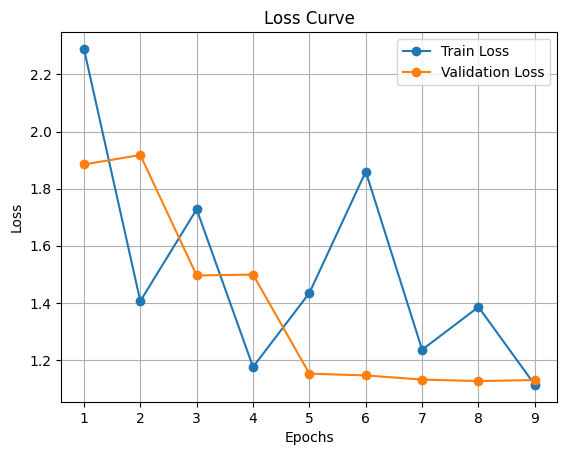

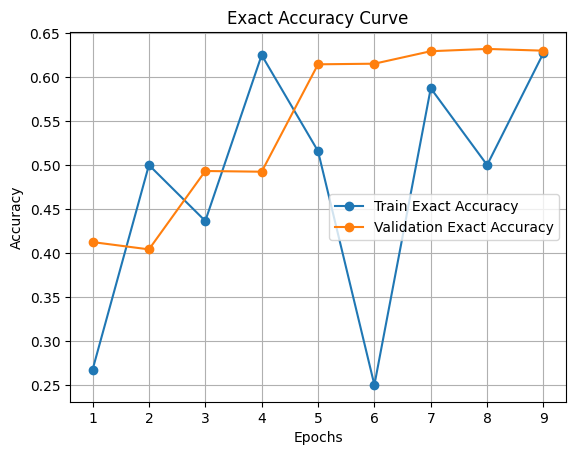

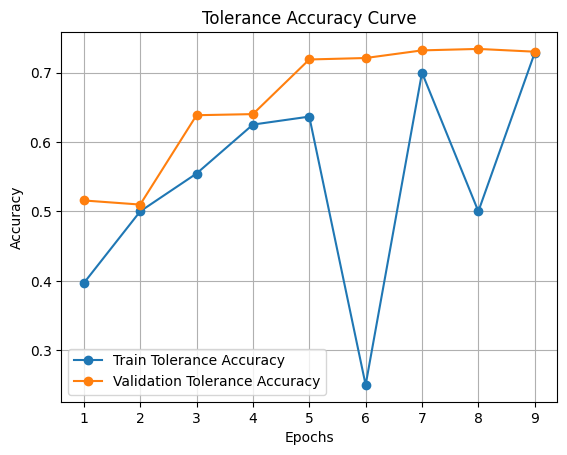

In [2]:
import matplotlib.pyplot as plt

# ==============================
# 1. EPOCHS
# ==============================
epochs = list(range(1, 10))  # till epoch 9

# ==============================
# 2. LOSS VALUES (from your logs)
# ==============================
train_loss = [2.2892, 1.4062, 1.7278, 1.1757, 1.4349, 1.8598, 1.2361, 1.3858, 1.1129]
val_loss   = [1.8847, 1.9178, 1.4961, 1.4991, 1.1524, 1.1461, 1.1316, 1.1263, 1.13]

# ==============================
# 3. EXACT ACCURACY
# ==============================
train_acc = [0.2673, 0.50, 0.4364, 0.6250, 0.5158, 0.25, 0.5873, 0.50, 0.6274]
val_acc   = [0.4124, 0.4041, 0.4932, 0.4924, 0.6145, 0.6152, 0.6294, 0.6320, 0.63]

# ==============================
# 4. TOLERANCE ACCURACY
# ==============================
train_tol = [0.3967, 0.50, 0.5545, 0.6250, 0.6365, 0.25, 0.6998, 0.50, 0.7284]
val_tol   = [0.5157, 0.5098, 0.6385, 0.6401, 0.7188, 0.7209, 0.7319, 0.7340, 0.73]

# ==============================
# 5. LOSS GRAPH
# ==============================
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# ==============================
# 6. EXACT ACCURACY GRAPH
# ==============================
plt.figure()
plt.plot(epochs, train_acc, marker='o', label='Train Exact Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Exact Accuracy')
plt.title("Exact Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# ==============================
# 7. TOLERANCE ACCURACY GRAPH
# ==============================
plt.figure()
plt.plot(epochs, train_tol, marker='o', label='Train Tolerance Accuracy')
plt.plot(epochs, val_tol, marker='o', label='Validation Tolerance Accuracy')
plt.title("Tolerance Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()